In [2]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import os

In [3]:
base_path = "spikes_repo"
dataset_name = "mnist"
latent_dim = 256

file_path = os.path.join(base_path, dataset_name,
                        "val_spike_all_{}.npy".format(latent_dim))

In [4]:
# Load the data
z_data = np.load(file_path)

if z_data.shape[1] == latent_dim:
    print("checked!")
else:
    print("wrong files")

# Inspect the shape of the data
z_data.shape
# Calculate the mean and variance along the 0-axis (across the samples for each feature)
z_mean = np.mean(z_data, axis=0)
z_var = np.var(z_data, axis=0)


checked!


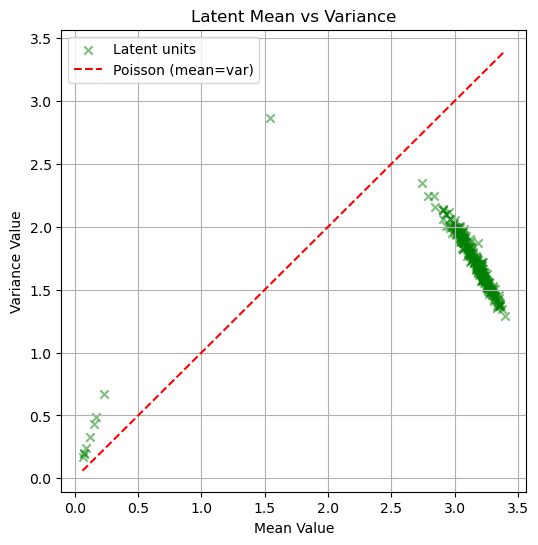

<Figure size 640x480 with 0 Axes>

In [5]:
plt.figure(figsize=(6, 6))
plt.scatter(z_mean, z_var, alpha=0.5, color='green',label='Latent units',marker='x')
plt.plot([min(z_mean), max(z_mean)], [min(z_mean), max(z_mean)], color='red', linestyle='--', label='Poisson (mean=var)')

# Set equal scaling for both axes
# plt.axis('equal')
# plt.xlim(0.55, max(z_mean))
plt.title('Latent Mean vs Variance')
plt.xlabel('Mean Value')
plt.ylabel('Variance Value')
plt.legend()
# plt.xlim(0.6)

plt.grid(True)
plt.show()
plt.tight_layout()
# fig.savefig("mean_var.pdf")

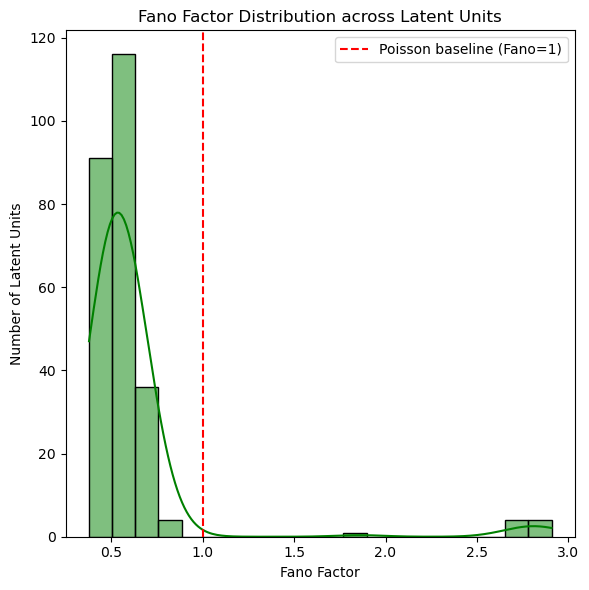

In [6]:
fano_factors = z_var / (z_mean + 1e-8)

fano_fig = plt.figure(figsize=(6, 6))
sns.histplot(fano_factors, bins=20, kde=True, color='green')
plt.axvline(1.0, color='red', linestyle='--', label='Poisson baseline (Fano=1)')
plt.title('Fano Factor Distribution across Latent Units')
plt.xlabel('Fano Factor')
plt.ylabel('Number of Latent Units')
plt.legend()
plt.tight_layout()